# Inference — test set วันสอบ (Project 1)

**วิธีใช้วันสอบ**
1. วางโฟลเดอร์ภาพทดสอบไว้ที่ `test_dataset/` ใน root โปรเจกต์ (หรือแก้ `TEST_DIR` ในเซลล์ 1)
2. ถ้ามีไฟล์ template ที่อาจารย์แจก (เช่น `Project_1-InputOutput.csv`) วางไว้ที่ root ด้วย จะได้ผลเรียงตรงตามลำดับแถวของ Google Sheet
3. เลือก kernel **Thai HCR (.venv)** แล้ว **Run All**
4. เปิด `submission/paste_to_sheet.txt` คัดลอกทั้งคอลัมน์ไปวางในช่องกลุ่มตัวเองใน Google Sheet

ผลลัพธ์เป็น **class_id 3 หลัก** ตาม `Mapping.csv` (72 คลาส)

**โมเดล**: ensemble ของ v1 + v3 (เฉลี่ย softmax) — ตั้งใน `CKPT_PATHS` เซลล์ 1
ถ้ามีปัญหา ลบ `best_resnet50_v3.pt` ออกจาก list จะกลับไปใช้ v1 เดี่ยวทันที

ไฟล์นี้รันได้อิสระ ไม่ต้องเปิด notebook อื่น และไม่ต้องเทรนใหม่

In [6]:
# 1. Config
import os, csv, re, time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
TEST_DIR     = Path(os.environ.get("TEST_DIR", PROJECT_ROOT / "test_dataset"))        # โฟลเดอร์ภาพทดสอบ
TEMPLATE_CSV = Path(os.environ.get("TEMPLATE_CSV", PROJECT_ROOT / "Project_1-InputOutput.csv"))  # ไฟล์ที่อาจารย์แจก (ถ้ามี)
# TEMPLATE_CSV = Path(os.environ.get("TEMPLATE_CSV", PROJECT_ROOT / "rehearsal_answers.csv"))
MAPPING_CSV  = PROJECT_ROOT / "Mapping.csv"
# โมเดลที่ใช้ทำนาย: ใส่ไฟล์เดียว = ทำนายด้วยโมเดลนั้น · ใส่หลายไฟล์ = ensemble (เฉลี่ย softmax)
# ผลทดสอบบน PrintAksorn 31,668 ภาพ: v1 0.8594 · v3 0.8603 · ensemble 0.8686 (ดีกว่าโมเดลเดี่ยวที่ดีสุด +0.0084)
# ถ้าวันสอบมีปัญหา ลบบรรทัด v3 ออก -> กลับไปเป็น v1 เดี่ยวทันที
CKPT_PATHS   = [PROJECT_ROOT / "checkpoints" / "best_resnet50.pt",
                PROJECT_ROOT / "checkpoints" / "best_resnet50_v3.pt"]
OUT_DIR      = PROJECT_ROOT / "submission"; OUT_DIR.mkdir(exist_ok=True)

RESTRICT_TO_MAPPING = True     # ปิดคลาสที่ไม่มีใน Mapping.csv (ฅ ฆ ฌ ฎ ฦ ะ ำ ๋ ํ) ไม่ให้ทายออกมา
BATCH_SIZE = 128
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

print(f"TEST_DIR     {TEST_DIR}  (มีอยู่จริง: {TEST_DIR.is_dir()})")
print(f"TEMPLATE_CSV {TEMPLATE_CSV.name}  (มีอยู่จริง: {TEMPLATE_CSV.is_file()})")
print(f"MAPPING_CSV  {MAPPING_CSV.name}  (มีอยู่จริง: {MAPPING_CSV.is_file()})")
for p in CKPT_PATHS:
    print(f"CKPT         {p.name}  (มีอยู่จริง: {p.is_file()})")

TEST_DIR     /Users/patcharapongvech/Desktop/Phet_folder/Year 3/Deep Learning/Proj./CNN/Project-1-Thai-Character-Number-Recognition/test_dataset  (มีอยู่จริง: True)
TEMPLATE_CSV Project_1-InputOutput.csv  (มีอยู่จริง: True)
MAPPING_CSV  Mapping.csv  (มีอยู่จริง: True)
CKPT         best_resnet50.pt  (มีอยู่จริง: True)
CKPT         best_resnet50_v3.pt  (มีอยู่จริง: True)


In [7]:
# 2. Mapping: รหัสโฟลเดอร์ TIS-620 -> class_id 3 หลัก (อ่านจาก Mapping.csv, มีสำรองฝังไว้เผื่อไฟล์หาย)
MAPPING_FALLBACK = {161:101,162:102,163:103,164:104,167:105,168:106,169:107,170:108,171:109,173:110,
                    175:111,176:112,177:113,178:114,179:115,180:116,181:117,182:118,183:119,184:120,
                    185:121,186:122,187:123,188:124,189:125,190:126,191:127,192:128,193:129,194:130,
                    195:131,196:132,197:133,199:134,200:135,201:136,202:137,203:138,204:139,205:140,
                    206:141,207:201,209:202,210:203,212:204,213:205,214:206,215:207,216:208,217:209,
                    224:210,225:211,226:212,227:213,228:214,229:215,230:216,231:217,232:218,233:219,
                    234:220,236:221,240:301,241:302,242:303,243:304,244:305,245:306,246:307,247:308,
                    248:309,249:310}
if MAPPING_CSV.is_file():
    with open(MAPPING_CSV, encoding="utf-8-sig") as fh:          # utf-8-sig: ไฟล์จากอาจารย์มี BOM
        CODE_TO_CLASSID = {int(r["folder"]): int(r["class_id"]) for r in csv.DictReader(fh)}
    print(f"อ่าน Mapping.csv ได้ {len(CODE_TO_CLASSID)} คลาส · ตรงกับสำรองที่ฝังไว้: {CODE_TO_CLASSID == MAPPING_FALLBACK}")
else:
    CODE_TO_CLASSID = MAPPING_FALLBACK
    print(f"ไม่พบ Mapping.csv -> ใช้ค่าสำรองที่ฝังไว้ {len(CODE_TO_CLASSID)} คลาส")
assert len(CODE_TO_CLASSID) == 72

อ่าน Mapping.csv ได้ 72 คลาส · ตรงกับสำรองที่ฝังไว้: True


In [8]:
# 3. Preprocessing (ชุดเดียวกับตอนเทรนทุกค่าพารามิเตอร์)
import cv2
import numpy as np
from PIL import Image
from skimage.filters import threshold_sauvola
from skimage.measure import label as cc_label

TARGET, MARGIN = 64, 4

def load_gray(path) -> np.ndarray:
    with Image.open(path) as im:
        return np.asarray(im.convert("L"), dtype=np.uint8)

def border_dark_fraction(g):
    return float((np.concatenate([g[0], g[-1], g[:, 0], g[:, -1]]) < 128).mean())

def normalize_polarity(g):
    if int(g.max()) - int(g.min()) < 30: return g
    return 255 - g if border_dark_fraction(g) >= 0.97 else g

def sauvola_binarize(g, k: float = 0.2):
    if int(g.max()) - int(g.min()) < 30:
        return np.full(g.shape, g.mean() < 128)
    h, w = g.shape
    win = max(3, min(25, (min(h, w) // 2) | 1))
    t = threshold_sauvola(g, window_size=win, k=k)
    bg = float(np.percentile(g, 99))
    ink = ((g < t) | (g < 0.5 * bg)) & (g < bg - 30)
    lab = cc_label(ink, connectivity=2)
    if lab.max() > 1:
        areas = np.bincount(lab.ravel()); areas[0] = 0
        ink = np.isin(lab, np.flatnonzero(areas >= 0.01 * areas.sum()))
    return ink

def tight_crop(mask):
    ys, xs = np.nonzero(mask)
    if len(ys) == 0: return mask
    return mask[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

def resize_keep_aspect(mask, box: int = TARGET - 2 * MARGIN):
    h, w = mask.shape
    s = box / max(h, w)
    nh, nw = max(1, round(h * s)), max(1, round(w * s))
    return cv2.resize(mask.astype(np.uint8) * 255, (nw, nh),
                      interpolation=cv2.INTER_AREA if s < 1 else cv2.INTER_LINEAR)

def letterbox_centroid(glyph, size: int = TARGET):
    h, w = glyph.shape
    m = cv2.moments(glyph, binaryImage=False)
    cy, cx = (m["m01"] / m["m00"], m["m10"] / m["m00"]) if m["m00"] > 0 else (h / 2, w / 2)
    top  = int(np.clip(round(size / 2 - cy), 0, size - h))
    left = int(np.clip(round(size / 2 - cx), 0, size - w))
    canvas = np.zeros((size, size), np.uint8)
    canvas[top:top + h, left:left + w] = glyph
    return canvas

def preprocess(path) -> np.ndarray:
    return letterbox_centroid(resize_keep_aspect(tight_crop(sauvola_binarize(normalize_polarity(load_gray(path))))))

print("preprocess พร้อมใช้งาน")

preprocess พร้อมใช้งาน


In [9]:
# 4. โหลดโมเดล + checkpoint
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50

device = "mps" if torch.backends.mps.is_available() else "cpu"
ckpts = [torch.load(p, map_location=device) for p in CKPT_PATHS]
ckpt  = ckpts[0]
IDX_TO_CHAR, CLASS_CODES = ckpt["idx_to_char"], ckpt["class_codes"]
NUM_CLASSES, INPUT_SIZE  = ckpt["num_classes"], ckpt["input_size"]
GRAY_MEAN, GRAY_STD      = ckpt["gray_mean"], ckpt["gray_std"]

# ทุก checkpoint ต้องใช้ class mapping และค่า preprocess/normalize ชุดเดียวกัน ไม่งั้นเฉลี่ยกันไม่ได้
for p, ck in zip(CKPT_PATHS[1:], ckpts[1:]):
    assert ck["idx_to_char"] == IDX_TO_CHAR,  f"{p.name}: idx_to_char ไม่ตรงกับตัวแรก"
    assert ck["target"] == ckpt["target"] and ck["input_size"] == INPUT_SIZE, f"{p.name}: ขนาดภาพไม่ตรงกัน"
    assert ck["gray_mean"] == GRAY_MEAN and ck["gray_std"] == GRAY_STD,       f"{p.name}: ค่า normalize ไม่ตรงกัน"

class ThaiHCRNet(nn.Module):
    def __init__(self, num_classes, input_size=INPUT_SIZE):
        super().__init__()
        net = resnet50(weights=None)
        old = net.conv1
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad(): net.conv1.weight.copy_(old.weight.sum(dim=1, keepdim=True))
        net.fc = nn.Linear(net.fc.in_features, num_classes)
        self.net, self.input_size = net, input_size
    def forward(self, x):
        if x.shape[-1] != self.input_size:
            x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return self.net(x)

models = []
for ck in ckpts:
    m = ThaiHCRNet(NUM_CLASSES).to(device)
    m.load_state_dict(ck["model_state"], strict=True)
    m.eval(); models.append(m)

# คลาสของโมเดลที่ไม่มีใน Mapping -> ปิดไม่ให้ทาย
valid = torch.tensor([code in CODE_TO_CLASSID for code in CLASS_CODES])
blocked = [IDX_TO_CHAR[i] for i in range(NUM_CLASSES) if not valid[i]]
mode = "โมเดลเดียว" if len(models) == 1 else f"ensemble {len(models)} โมเดล (เฉลี่ย softmax)"
print(f"device {device} · {mode} · {NUM_CLASSES} คลาส")
for p, ck in zip(CKPT_PATHS, ckpts):
    print(f"   {p.name:<26} epoch {ck['epoch']} · val acc {ck['val_acc']:.4f} · val macro F1 {ck['val_f1']:.4f}")
print(f"คลาสที่ทายได้จริง {int(valid.sum())} · ปิดไว้ {len(blocked)} คลาส: {' '.join(blocked)}" if RESTRICT_TO_MAPPING
      else "ไม่จำกัดคลาส (RESTRICT_TO_MAPPING = False)")

device mps · ensemble 2 โมเดล (เฉลี่ย softmax) · 81 คลาส
   best_resnet50.pt           epoch 13 · val acc 0.9715 · val macro F1 0.9671
   best_resnet50_v3.pt        epoch 11 · val acc 0.9676 · val macro F1 0.9632
คลาสที่ทายได้จริง 72 · ปิดไว้ 9 คลาส: ฅ ฆ ฌ ฎ ฦ ะ ำ ๋ ํ


In [10]:
# 5. หาไฟล์ภาพทดสอบ + จัดลำดับให้ตรงกับ template ของอาจารย์
def stem_key(p):
    """ts_img_001.jpg -> ts_img_001 (ใช้จับคู่กับ gt_path ที่ไม่มีนามสกุล)"""
    return Path(str(p)).stem

assert TEST_DIR.is_dir(), f"ไม่พบโฟลเดอร์ {TEST_DIR} — แก้ TEST_DIR ในเซลล์ 1"
found = {stem_key(p): p for p in sorted(TEST_DIR.rglob("*")) if p.is_file() and p.suffix.lower() in IMG_EXTS}
print(f"พบภาพใน {TEST_DIR.name}/ : {len(found)} ไฟล์ · นามสกุล {sorted({p.suffix.lower() for p in found.values()})}")

order, missing = [], []
if TEMPLATE_CSV.is_file():
    with open(TEMPLATE_CSV, encoding="utf-8-sig", errors="replace") as fh:
        rows_t = [r for r in csv.DictReader(fh)]
    col = next(c for c in rows_t[0] if c.strip().lower() == "gt_path")
    for r in rows_t:
        gt = (r[col] or "").strip()
        if not gt: continue
        k = stem_key(gt)
        (order if k in found else missing).append((gt, found.get(k)))
    print(f"ใช้ลำดับจาก {TEMPLATE_CSV.name}: {len(order)} แถว · ไม่พบไฟล์ {len(missing)} แถว")
    if missing: print("   ตัวอย่างที่ไม่พบ:", [g for g, _ in missing[:5]])
    extra = [k for k in found if k not in {stem_key(g) for g, _ in order + missing}]
    if extra: print(f"   ภาพที่มีในโฟลเดอร์แต่ไม่มีใน template: {len(extra)} -> {extra[:5]}")
else:
    nat = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]   # เรียงแบบธรรมชาติ
    order = [(f"./{TEST_DIR.name}/{p.name}", p) for _, p in sorted(found.items(), key=lambda kv: nat(kv[0]))]
    print(f"ไม่พบ template -> เรียงตามชื่อไฟล์: {len(order)} ภาพ")
print("ตัวอย่าง 5 แถวแรก:", [g for g, _ in order[:5]])

พบภาพใน test_dataset/ : 500 ไฟล์ · นามสกุล ['.jpg']
ใช้ลำดับจาก Project_1-InputOutput.csv: 500 แถว · ไม่พบไฟล์ 0 แถว
ตัวอย่าง 5 แถวแรก: ['./test_dataset/ts_img_00001', './test_dataset/ts_img_00002', './test_dataset/ts_img_00003', './test_dataset/ts_img_00004', './test_dataset/ts_img_00005']


In [11]:
# 6. รัน inference (ต้องเสร็จภายใน 30 นาที — ปกติ ~500 ภาพใช้ไม่กี่วินาที)
t0 = time.perf_counter()
paths = [p for _, p in order]
preds, confs, failed = [], [], []

imgs = []
for p in paths:
    try:
        imgs.append(preprocess(p))
    except Exception as e:                      # ภาพเสีย -> ใส่ภาพว่างไว้ ไม่ให้ทั้ง batch พัง
        failed.append((p.name, repr(e))); imgs.append(np.zeros((TARGET, TARGET), np.uint8))
X = np.stack(imgs)
t_pre = time.perf_counter() - t0

with torch.no_grad():
    for s0 in range(0, len(X), BATCH_SIZE):
        x = torch.from_numpy(X[s0:s0 + BATCH_SIZE]).unsqueeze(1).float() / 255.0
        x = ((x - GRAY_MEAN) / GRAY_STD).to(device)
        prob = None
        for m in models:                                  # เฉลี่ย softmax ของทุกโมเดล (โมเดลเดียว = ได้ผลเท่าเดิม)
            logits = m(x).float().cpu()
            if RESTRICT_TO_MAPPING: logits[:, ~valid] = float("-inf")
            prob = logits.softmax(1) if prob is None else prob + logits.softmax(1)
        prob /= len(models)
        c, i = prob.max(1)
        preds.extend(i.tolist()); confs.extend(c.tolist())

elapsed = time.perf_counter() - t0
print(f"ทำนาย {len(preds)} ภาพ ด้วย {len(models)} โมเดล ใน {elapsed:.1f}s "
      f"(preprocess {t_pre:.1f}s) · เฉลี่ย {1000 * elapsed / max(len(preds),1):.1f} ms/ภาพ")
if failed: print(f"⚠️ ภาพที่อ่านไม่ได้ {len(failed)}: {failed[:5]}")
blank = int((X.max(axis=(1, 2)) == 0).sum())
if blank: print(f"⚠️ ภาพที่ binarize แล้วว่างเปล่า {blank} ภาพ (ผลอาจมั่ว)")

ทำนาย 500 ภาพ ด้วย 2 โมเดล ใน 2.8s (preprocess 0.3s) · เฉลี่ย 5.7 ms/ภาพ
⚠️ ภาพที่ binarize แล้วว่างเปล่า 2 ภาพ (ผลอาจมั่ว)


In [12]:
# 7. เขียนไฟล์ผลลัพธ์
class_ids = [CODE_TO_CLASSID[CLASS_CODES[i]] for i in preds]
chars     = [IDX_TO_CHAR[i] for i in preds]

with open(OUT_DIR / "predictions.csv", "w", newline="", encoding="utf-8-sig") as fh:
    w = csv.writer(fh); w.writerow(["gt_path", "pred_class_id", "pred_char", "confidence", "file"])
    for (gt, p), cid, ch, cf in zip(order, class_ids, chars, confs):
        w.writerow([gt, cid, ch, round(cf, 4), p.name])

with open(OUT_DIR / "paste_to_sheet.txt", "w") as fh:       # คัดลอกทั้งก้อนไปวางในคอลัมน์กลุ่มตัวเอง
    fh.write("\n".join(str(c) for c in class_ids) + "\n")

print(f"เขียนแล้ว: {OUT_DIR.name}/predictions.csv · {OUT_DIR.name}/paste_to_sheet.txt ({len(class_ids)} แถว)\n")
print(f"{'gt_path':<34}{'class_id':>9}{'ตัวอักษร':>10}{'conf':>8}")
for (gt, _), cid, ch, cf in list(zip(order, class_ids, chars, confs))[:20]:
    print(f"{gt:<34}{cid:>9}{ch:>8}{cf:>10.3f}")

low = sorted([(cf, gt, ch, cid) for (gt, _), cid, ch, cf in zip(order, class_ids, chars, confs)])[:10]
print(f"\n10 ภาพที่โมเดลมั่นใจน้อยที่สุด (ควรตรวจด้วยตา):")
for cf, gt, ch, cid in low: print(f"  {gt:<34}{cid:>6}  {ch}  conf {cf:.3f}")

เขียนแล้ว: submission/predictions.csv · submission/paste_to_sheet.txt (500 แถว)

gt_path                            class_id  ตัวอักษร    conf
./test_dataset/ts_img_00001             101       ก     0.950
./test_dataset/ts_img_00002             102       ข     0.958
./test_dataset/ts_img_00003             103       ฃ     0.716
./test_dataset/ts_img_00004             104       ค     0.955
./test_dataset/ts_img_00005             105       ง     0.938
./test_dataset/ts_img_00006             106       จ     0.955
./test_dataset/ts_img_00007             107       ฉ     0.951
./test_dataset/ts_img_00008             108       ช     0.891
./test_dataset/ts_img_00009             109       ซ     0.914
./test_dataset/ts_img_00010             110       ญ     0.951
./test_dataset/ts_img_00011             111       ฏ     0.956
./test_dataset/ts_img_00012             112       ฐ     0.913
./test_dataset/ts_img_00013             113       ฑ     0.906
./test_dataset/ts_img_00014             114       ฒ

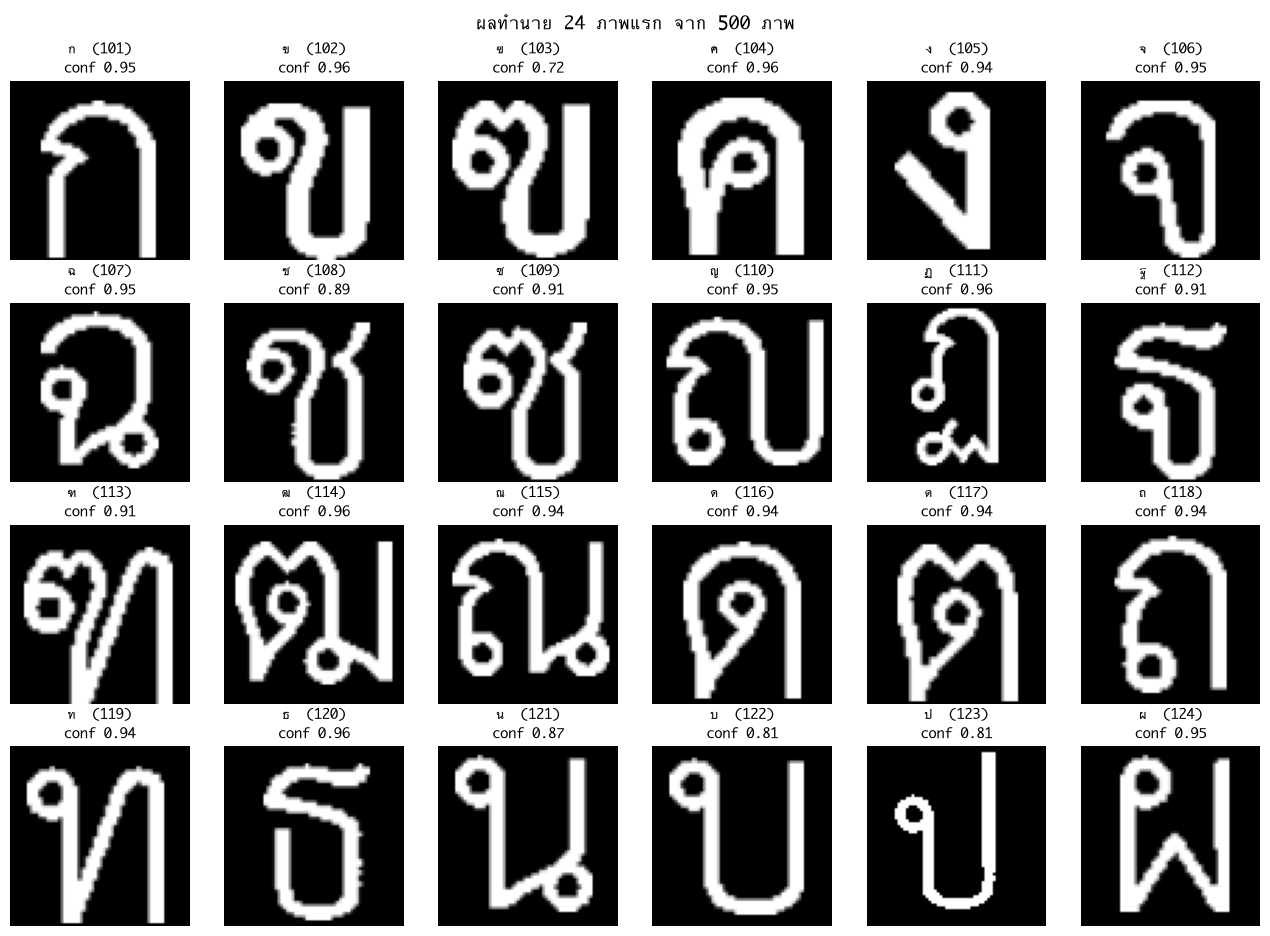

In [13]:
# 8. ตรวจด้วยตา: ภาพหลัง preprocess + ผลทำนาย 24 ภาพแรก
import matplotlib.pyplot as plt
from matplotlib import font_manager
for f in ["/System/Library/Fonts/Supplemental/Ayuthaya.ttf", "/System/Library/Fonts/Thonburi.ttc"]:
    if Path(f).exists():
        font_manager.fontManager.addfont(f); plt.rcParams["font.family"] = font_manager.FontProperties(fname=f).get_name(); break

n = min(24, len(X))
fig, axes = plt.subplots(4, 6, figsize=(13, 9.5))
for ax, i in zip(axes.ravel(), range(n)):
    ax.imshow(X[i], cmap="gray"); ax.axis("off")
    ax.set_title(f"{chars[i]}  ({class_ids[i]})\nconf {confs[i]:.2f}", fontsize=10)
for ax in axes.ravel()[n:]: ax.axis("off")
plt.suptitle(f"ผลทำนาย {n} ภาพแรก จาก {len(X)} ภาพ", fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "preview.png", dpi=120); plt.show()

In [14]:
# 9. (ถ้ามีเฉลย) ตรวจคะแนน — วันสอบข้ามเซลล์นี้ได้ ใช้ตอนซ้อมเท่านั้น
gt_col = None
if TEMPLATE_CSV.is_file():
    with open(TEMPLATE_CSV, encoding="utf-8-sig", errors="replace") as fh:
        rows_t = {r[next(c for c in r if c.strip().lower() == "gt_path")].strip(): r for r in csv.DictReader(fh)}
    key = next((c for c in next(iter(rows_t.values())) if c.strip().lower() == "gt_class_id"), None)
    truth = {g: rows_t[g][key].strip() for g in rows_t if key and rows_t[g].get(key, "").strip().isdigit()}
    have = [(g, cid) for (g, _), cid in zip(order, class_ids) if g in truth]
    if len(truth) >= 10 and len(set(truth.values())) > 1:      # มีเฉลยจริง ไม่ใช่ค่า placeholder
        correct = sum(1 for g, cid in have if str(cid) == truth[g])
        print(f"เทียบกับเฉลยใน {TEMPLATE_CSV.name}: {correct}/{len(have)} = {correct / max(len(have),1):.2%}")
        wrong = [(g, cid, truth[g]) for g, cid in have if str(cid) != truth[g]]
        print("ตัวอย่างที่ผิด:", wrong[:10])
    else:
        print(f"ไม่มีเฉลยใน {TEMPLATE_CSV.name} (คอลัมน์ gt_class_id ว่างหรือเป็น placeholder) — ข้ามการตรวจคะแนน")
else:
    print("ไม่มี template — ข้ามการตรวจคะแนน")

ไม่มีเฉลยใน Project_1-InputOutput.csv (คอลัมน์ gt_class_id ว่างหรือเป็น placeholder) — ข้ามการตรวจคะแนน
